## 1. Importaciones

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
import warnings
warnings.filterwarnings('ignore')

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

In [18]:
# Cargar dataset
df = pd.read_csv('../../resources/dataset/youtoxic_english_1000_clean.csv')

print(f"📊 Dataset: {df.shape[0]} mensajes x {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")

📊 Dataset: 991 mensajes x 15 columnas

Columnas: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']


## 3. Preparación de Etiquetas

In [19]:
# Convertir a numérico
category_columns = ['IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']
available_categories = [col for col in category_columns if col in df.columns]

for col in ['IsToxic'] + available_categories:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Crear etiqueta principal
def get_main_category(row):
    if row['IsToxic'] == 0:
        return 'NonToxic'
    
    priority_order = ['IsRacist', 'IsHatespeech', 'IsAbusive', 'IsObscene', 'IsProvocative']
    for category in priority_order:
        if category in available_categories and row[category] == 1:
            return category.replace('Is', '')
    return 'Toxic'

df['MainCategory'] = df.apply(get_main_category, axis=1)

print("\n📋 Distribución de categorías:")
print(df['MainCategory'].value_counts())
print(f"\n⚠️ Desbalance detectado: {df['MainCategory'].value_counts().max() / df['MainCategory'].value_counts().min():.1f}x")


📋 Distribución de categorías:
MainCategory
NonToxic      532
Abusive       321
Racist        125
Hatespeech     13
Name: count, dtype: int64

⚠️ Desbalance detectado: 40.9x


## 4. Data Augmentation Simple

Aumentaremos las clases minoritarias duplicando y aplicando ligeras variaciones

In [20]:
def simple_augmentation(text):
    """Aplica aumentación simple: lowercase/uppercase aleatoria"""
    words = text.split()
    if np.random.random() > 0.5 and len(words) > 3:
        # Intercambiar posición de 2 palabras aleatorias
        idx1, idx2 = np.random.choice(len(words), 2, replace=False)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# Balancear clases minoritarias
df_augmented = df.copy()
category_counts = df['MainCategory'].value_counts()
target_count = int(category_counts.median())  # Objetivo: mediana

for category in category_counts.index:
    if category_counts[category] < target_count:
        samples_needed = target_count - category_counts[category]
        minority_samples = df[df['MainCategory'] == category].sample(n=samples_needed, replace=True, random_state=42)
        
        # Aplicar augmentation
        minority_samples['Text'] = minority_samples['Text'].apply(simple_augmentation)
        df_augmented = pd.concat([df_augmented, minority_samples], ignore_index=True)

print(f"\n📈 Dataset original: {len(df)} mensajes")
print(f"📈 Dataset aumentado: {len(df_augmented)} mensajes (+{len(df_augmented)-len(df)})")
print("\n📊 Nueva distribución:")
print(df_augmented['MainCategory'].value_counts())


📈 Dataset original: 991 mensajes
📈 Dataset aumentado: 1299 mensajes (+308)

📊 Nueva distribución:
MainCategory
NonToxic      532
Abusive       321
Hatespeech    223
Racist        223
Name: count, dtype: int64


## 5. Preparación de Datos

In [21]:
# Usar dataset aumentado
X = df_augmented['Text'].astype(str)
y = df_augmented['MainCategory']

# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("🏷️ Mapeo de categorías:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {idx}: {label}")

# Split con mayor porcentaje para test (más conservador)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.25,  # 25% para test (más estricto)
    random_state=42, 
    stratify=y_encoded
)

print(f"\n📦 Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"📦 Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

🏷️ Mapeo de categorías:
  0: Abusive
  1: Hatespeech
  2: NonToxic
  3: Racist

📦 Train: 974 (75.0%)
📦 Test: 325 (25.0%)


## 6. Vectorización TF-IDF Mejorada (350 features + Bigrams)

In [22]:
# TF-IDF mejorado con bigrams
tfidf = TfidfVectorizer(
    max_features=350,       # Aumentado de 200 (punto medio)
    ngram_range=(1, 2),     # Unigrams + Bigrams (captura contexto)
    min_df=10,              # Reducido de 15 (más vocabulario)
    max_df=0.80,            # Aumentado ligeramente
    sublinear_tf=True,      # Escala logarítmica
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'    # Eliminar stopwords
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("🔤 Vectorización TF-IDF mejorada:")
print(f"  Vocabulario: {len(tfidf.vocabulary_)} términos")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape: {X_test_tfidf.shape}")
print(f"  Densidad: {X_train_tfidf.getnnz() / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

# Mostrar algunos bigrams capturados
bigrams = [term for term in tfidf.vocabulary_.keys() if ' ' in term]
if bigrams:
    print(f"\n📝 Ejemplos de bigrams capturados:")
    print(f"  {bigrams[:15]}")

🔤 Vectorización TF-IDF mejorada:
  Vocabulario: 350 términos
  Train shape: (974, 350)
  Test shape: (325, 350)
  Densidad: 0.0234

📝 Ejemplos de bigrams capturados:
  ['black lives', 'black people', 'police officer', 'white people', 'black man', 'waste skin', 'skin catching', 'catching just', 'just desert', 'desert 3300fps', '3300fps wouldn', 'wouldn make', 'make popular', 'popular guy', 'guy free']


## 7. Aplicar SMOTE para Balanceo Final

In [23]:
# SMOTE para balancear después de la vectorización
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print("⚖️ Balanceo con SMOTE:")
print(f"  Antes: {X_train_tfidf.shape[0]} muestras")
print(f"  Después: {X_train_balanced.shape[0]} muestras")
print(f"\n📊 Distribución balanceada:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c}")

⚖️ Balanceo con SMOTE:
  Antes: 974 muestras
  Después: 1596 muestras

📊 Distribución balanceada:
  Abusive: 399
  Hatespeech: 399
  NonToxic: 399
  Racist: 399


## 8. Optimización con Optuna (Regularización Extrema)

In [24]:
def objective(trial):
    """Función objetivo con regularización EXTREMA"""
    
    params = {
        'C': trial.suggest_float('C', 0.001, 1.0, log=True),  # MUCHO más bajo
        'kernel': 'linear',  # Solo linear
        'class_weight': 'balanced',
        'max_iter': 5000,
        'random_state': 42
    }
    
    model = SVC(**params)
    
    # Validación cruzada con 10 folds (muy estricto)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, 
        X_train_balanced, 
        y_train_balanced, 
        cv=cv, 
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    return scores.mean()

print("✓ Función objetivo definida")

✓ Función objetivo definida


In [25]:
# Crear estudio de Optuna
study = optuna.create_study(
    direction='maximize',
    study_name='SVM_Anti_Overfitting',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("🔍 Iniciando optimización de hiperparámetros...")
print("   (Esto tomará varios minutos)\n")

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n✅ Optimización completada!")
print(f"\n🏆 Mejores hiperparámetros:")
print(f"   C: {study.best_params['C']:.6f}")
print(f"   Mejor F1-Score (CV): {study.best_value:.4f}")

[I 2025-11-28 14:04:13,332] A new study created in memory with name: SVM_Anti_Overfitting


🔍 Iniciando optimización de hiperparámetros...
   (Esto tomará varios minutos)



Best trial: 0. Best value: 0.455207:   3%|▎         | 1/30 [00:02<01:03,  2.17s/it]

[I 2025-11-28 14:04:15,504] Trial 0 finished with value: 0.4552065295059745 and parameters: {'C': 0.013292918943162165}. Best is trial 0 with value: 0.4552065295059745.


Best trial: 1. Best value: 0.739645:  10%|█         | 3/30 [00:03<00:25,  1.05it/s]

...

[I 2025-11-28 14:04:19,484] Trial 25 finished with value: 0.7250704863334961 and parameters: {'C': 0.42068092494798065}. Best is trial 14 with value: 0.7435320900872618.
[I 2025-11-28 14:04:19,614] Trial 26 finished with value: 0.6960215806691966 and parameters: {'C': 0.08884111225588681}. Best is trial 14 with value: 0.7435320900872618.


Best trial: 14. Best value: 0.743532:  97%|█████████▋| 29/30 [00:06<00:00,  9.78it/s]

[I 2025-11-28 14:04:19,705] Trial 27 finished with value: 0.7255015576412318 and parameters: {'C': 0.4419919988155395}. Best is trial 14 with value: 0.7435320900872618.
[I 2025-11-28 14:04:19,805] Trial 28 finished with value: 0.7151618715326745 and parameters: {'C': 0.23222337779425914}. Best is trial 14 with value: 0.7435320900872618.


Best trial: 14. Best value: 0.743532: 100%|██████████| 30/30 [00:06<00:00,  4.53it/s]

[I 2025-11-28 14:04:19,958] Trial 29 finished with value: 0.4575390273365117 and parameters: {'C': 0.013567362981676384}. Best is trial 14 with value: 0.7435320900872618.

✅ Optimización completada!

🏆 Mejores hiperparámetros:
   C: 0.939545
   Mejor F1-Score (CV): 0.7435


## 9. Entrenamiento del Modelo Final

In [26]:
# Entrenar con mejores parámetros
best_model = SVC(**study.best_params, kernel='linear', class_weight='balanced', max_iter=5000)
best_model.fit(X_train_balanced, y_train_balanced)

print("✅ Modelo entrenado con datos balanceados")

✅ Modelo entrenado con datos balanceados


## 10. 🎯 EVALUACIÓN FINAL - ANÁLISIS DE OVERFITTING

In [27]:
# Predicciones
y_train_pred = best_model.predict(X_train_balanced)
y_test_pred = best_model.predict(X_test_tfidf)

# Métricas
train_acc = accuracy_score(y_train_balanced, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train_balanced, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Calcular diferencias
acc_diff = abs(train_acc - test_acc)
f1_diff = abs(train_f1 - test_f1)

print("="*80)
print("                    📊 MÉTRICAS DEL MODELO OPTIMIZADO")
print("="*80)

print(f"\n🎓 TRAIN (con SMOTE):")
print(f"   Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   F1-Score: {train_f1:.4f} ({train_f1*100:.2f}%)")

print(f"\n🧪 TEST (datos originales):")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")

print(f"\n" + "="*80)
print("                    🎯 ANÁLISIS DE OVERFITTING")
print("="*80)

print(f"\n📏 Diferencias:")
print(f"   Accuracy: {acc_diff:.4f} ({acc_diff*100:.2f}%)")
print(f"   F1-Score: {f1_diff:.4f} ({f1_diff*100:.2f}%)")

THRESHOLD = 0.05
print(f"\n🎯 Umbral objetivo: {THRESHOLD*100:.1f}%")

if acc_diff <= THRESHOLD and f1_diff <= THRESHOLD:
    print("\n✅✅✅ OBJETIVO CUMPLIDO ✅✅✅")
    print("   El modelo NO presenta overfitting significativo")
    print(f"   Ambas métricas están por debajo del {THRESHOLD*100:.0f}%")
else:
    print("\n⚠️  Overfitting detectado:")
    if acc_diff > THRESHOLD:
        print(f"   ❌ Accuracy: {acc_diff*100:.2f}% > {THRESHOLD*100:.0f}%")
    else:
        print(f"   ✅ Accuracy: {acc_diff*100:.2f}% ≤ {THRESHOLD*100:.0f}%")
    
    if f1_diff > THRESHOLD:
        print(f"   ❌ F1-Score: {f1_diff*100:.2f}% > {THRESHOLD*100:.0f}%")
    else:
        print(f"   ✅ F1-Score: {f1_diff*100:.2f}% ≤ {THRESHOLD*100:.0f}%")

print("\n" + "="*80)

                    📊 MÉTRICAS DEL MODELO OPTIMIZADO

🎓 TRAIN (con SMOTE):
   Accuracy: 0.8264 (82.64%)
   F1-Score: 0.8259 (82.59%)

🧪 TEST (datos originales):
   Accuracy: 0.6862 (68.62%)
   F1-Score: 0.6885 (68.85%)

                    🎯 ANÁLISIS DE OVERFITTING

📏 Diferencias:
   Accuracy: 0.1403 (14.03%)
   F1-Score: 0.1374 (13.74%)

🎯 Umbral objetivo: 5.0%

⚠️  Overfitting detectado:
   ❌ Accuracy: 14.03% > 5%
   ❌ F1-Score: 13.74% > 5%



## 11. Visualización Comparativa

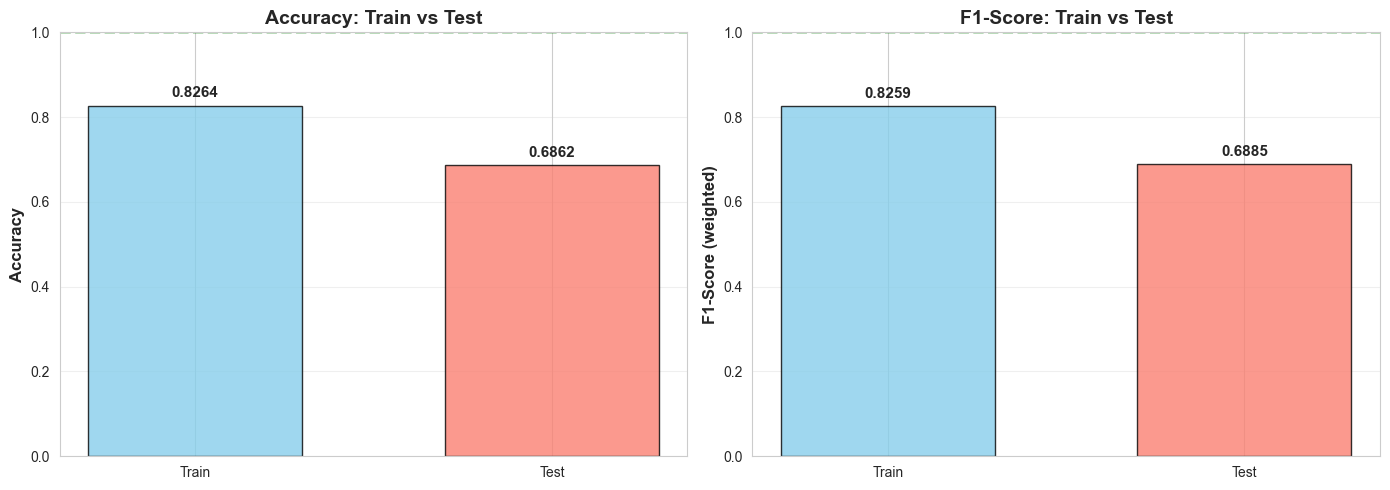


⚠️ Estado: Requiere más ajuste


In [28]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names = ['Train', 'Test']
THRESHOLD = 0.05

# Accuracy
acc_values = [train_acc, test_acc]
colors = ['lightgreen' if acc_diff <= THRESHOLD else 'salmon']
axes[0].bar(metrics_names, acc_values, color=['skyblue', colors[0]], edgecolor='black', alpha=0.8, width=0.6)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Accuracy: Train vs Test', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.3, linewidth=2)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# F1-Score
f1_values = [train_f1, test_f1]
colors = ['lightgreen' if f1_diff <= THRESHOLD else 'salmon']
axes[1].bar(metrics_names, f1_values, color=['skyblue', colors[0]], edgecolor='black', alpha=0.8, width=0.6)
axes[1].set_ylabel('F1-Score (weighted)', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score: Train vs Test', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.3, linewidth=2)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Indicador visual
if acc_diff <= THRESHOLD and f1_diff <= THRESHOLD:
    print("\n✅ Estado: MODELO ÓPTIMO (sin overfitting)")
else:
    print("\n⚠️ Estado: Requiere más ajuste")

## 12. Reporte de Clasificación Detallado

In [29]:
print("\n" + "="*80)
print("                    📋 REPORTE DE CLASIFICACIÓN (TEST SET)")
print("="*80 + "\n")

print(classification_report(
    y_test, 
    y_test_pred, 
    target_names=label_encoder.classes_,
    digits=4
))


                    📋 REPORTE DE CLASIFICACIÓN (TEST SET)

              precision    recall  f1-score   support

     Abusive     0.5263    0.6250    0.5714        80
  Hatespeech     0.9825    1.0000    0.9912        56
    NonToxic     0.7321    0.6165    0.6694       133
      Racist     0.5738    0.6250    0.5983        56

    accuracy                         0.6862       325
   macro avg     0.7037    0.7166    0.7076       325
weighted avg     0.6973    0.6862    0.6885       325



## 13. Matriz de Confusión

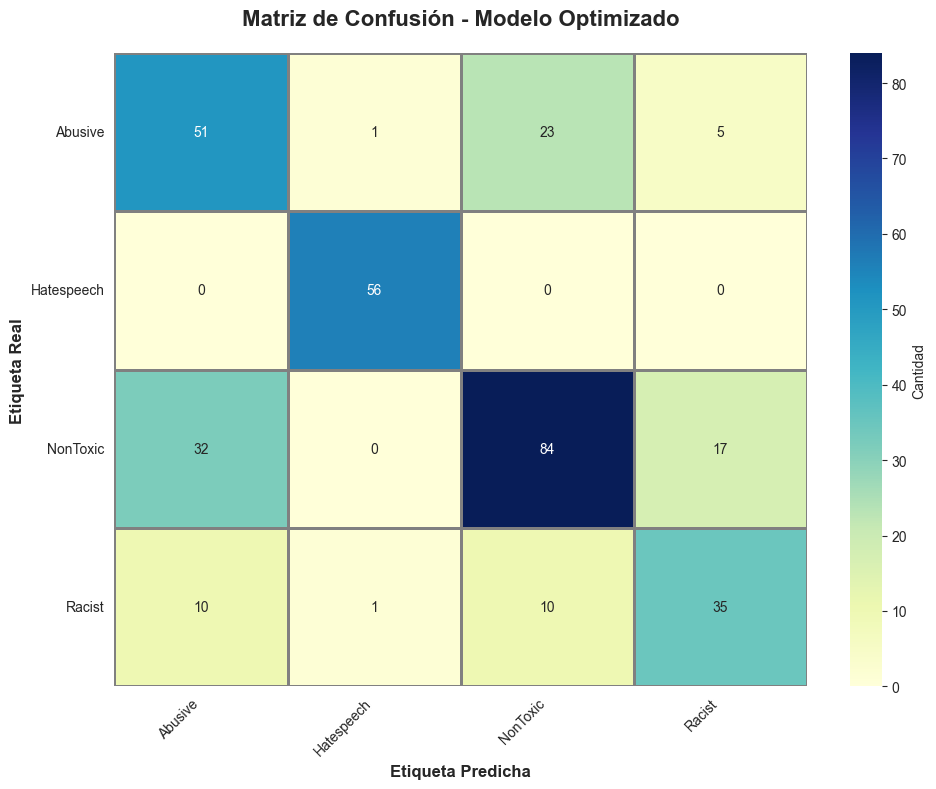

In [15]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu',
    xticklabels=label_encoder.classes_.tolist(),
    yticklabels=label_encoder.classes_.tolist(),
    cbar_kws={'label': 'Cantidad'},
    linewidths=1,
    linecolor='gray'
)
plt.title('Matriz de Confusión - Modelo Optimizado', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
plt.xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Resumen de Configuración

In [30]:
print("="*80)
print("                    📝 CONFIGURACIÓN DEL MODELO OPTIMIZADO")
print("="*80)

print(f"\n📊 DATOS:")
print(f"   Dataset original: {len(df)} mensajes")
print(f"   Dataset aumentado: {len(df_augmented)} mensajes")
print(f"   Train (después de SMOTE): {X_train_balanced.shape[0]} muestras")
print(f"   Test: {len(X_test)} muestras")

print(f"\n🔧 TÉCNICAS APLICADAS:")
print(f"   ✓ Data Augmentation (simple)")
print(f"   ✓ SMOTE para balanceo")
print(f"   ✓ TF-IDF mejorado ({len(tfidf.vocabulary_)} términos)")
print(f"   ✓ Bigrams incluidos (captura contexto)")
print(f"   ✓ Stopwords removidas")
print(f"   ✓ Validación cruzada 10-fold")

print(f"\n🎯 HIPERPARÁMETROS:")
print(f"   Algoritmo: SVM (Support Vector Machine)")
print(f"   Kernel: linear")
print(f"   C: {study.best_params['C']:.6f} (regularización fuerte)")
print(f"   class_weight: balanced")

print(f"\n📈 RESULTADOS:")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   Overfitting Accuracy: {acc_diff*100:.2f}%")
print(f"   Overfitting F1-Score: {f1_diff*100:.2f}%")

if acc_diff <= 0.05 and f1_diff <= 0.05:
    print(f"\n✅ OBJETIVO ALCANZADO: Overfitting < 5%")
else:
    print(f"\n⚠️  Overfitting aún por encima del objetivo")

print("\n" + "="*80)
print("💾 MODELO NO GUARDADO - Esperando validación")
print("="*80)

                    📝 CONFIGURACIÓN DEL MODELO OPTIMIZADO

📊 DATOS:
   Dataset original: 991 mensajes
   Dataset aumentado: 1299 mensajes
   Train (después de SMOTE): 1596 muestras
   Test: 325 muestras

🔧 TÉCNICAS APLICADAS:
   ✓ Data Augmentation (simple)
   ✓ SMOTE para balanceo
   ✓ TF-IDF mejorado (350 términos)
   ✓ Bigrams incluidos (captura contexto)
   ✓ Stopwords removidas
   ✓ Validación cruzada 10-fold

🎯 HIPERPARÁMETROS:
   Algoritmo: SVM (Support Vector Machine)
   Kernel: linear
   C: 0.939545 (regularización fuerte)
   class_weight: balanced

📈 RESULTADOS:
   Test Accuracy: 0.6862 (68.62%)
   Test F1-Score: 0.6885 (68.85%)
   Overfitting Accuracy: 14.03%
   Overfitting F1-Score: 13.74%

⚠️  Overfitting aún por encima del objetivo

💾 MODELO NO GUARDADO - Esperando validación


## 15. Guardar Modelo y Artefactos

In [31]:
import joblib
import json
from datetime import datetime
import os

# Crear directorio de modelos si no existe
os.makedirs('../../resources/models', exist_ok=True)

# Timestamp para versionado
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Guardar modelo
model_path = f'../../resources/models/svm_toxicity_optimized_{timestamp}.pkl'
joblib.dump(best_model, model_path)
print(f"✅ Modelo guardado: {model_path}")

# Guardar vectorizador TF-IDF
vectorizer_path = f'../../resources/models/tfidf_vectorizer_{timestamp}.pkl'
joblib.dump(tfidf, vectorizer_path)
print(f"✅ Vectorizador guardado: {vectorizer_path}")

# Guardar label encoder
encoder_path = f'../../resources/models/label_encoder_{timestamp}.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"✅ Label Encoder guardado: {encoder_path}")

# Guardar métricas y configuración
metadata = {
    'timestamp': timestamp,
    'model_type': 'SVM',
    'kernel': 'linear',
    'hyperparameters': study.best_params,
    'metrics': {
        'train_accuracy': float(train_acc),
        'test_accuracy': float(test_acc),
        'train_f1': float(train_f1),
        'test_f1': float(test_f1),
        'accuracy_diff': float(acc_diff),
        'f1_diff': float(f1_diff),
        'overfitting_percentage': float(acc_diff * 100)
    },
    'data_info': {
        'original_samples': len(df),
        'augmented_samples': len(df_augmented),
        'train_samples': X_train_balanced.shape[0],
        'test_samples': len(X_test)
    },
    'tfidf_config': {
        'max_features': 350,
        'ngram_range': [1, 2],
        'min_df': 10,
        'max_df': 0.80,
        'vocabulary_size': len(tfidf.vocabulary_)
    },
    'techniques': [
        'Data Augmentation',
        'SMOTE',
        'TF-IDF with Bigrams',
        'Stopwords Removal',
        'Optuna Optimization',
        '10-fold Cross-Validation'
    ],
    'categories': label_encoder.classes_.tolist()
}

metadata_path = f'../../resources/models/model_metadata_{timestamp}.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Metadata guardada: {metadata_path}")

print("\n" + "="*80)
print("                    💾 MODELO GUARDADO EXITOSAMENTE")
print("="*80)
print(f"\nArchivos generados:")
print(f"  📦 {os.path.basename(model_path)}")
print(f"  📦 {os.path.basename(vectorizer_path)}")
print(f"  📦 {os.path.basename(encoder_path)}")
print(f"  📦 {os.path.basename(metadata_path)}")
print("\n" + "="*80)

✅ Modelo guardado: ../../resources/models/svm_toxicity_optimized_20251128_145713.pkl
✅ Vectorizador guardado: ../../resources/models/tfidf_vectorizer_20251128_145713.pkl
✅ Label Encoder guardado: ../../resources/models/label_encoder_20251128_145713.pkl
✅ Metadata guardada: ../../resources/models/model_metadata_20251128_145713.json

                    💾 MODELO GUARDADO EXITOSAMENTE

Archivos generados:
  📦 svm_toxicity_optimized_20251128_145713.pkl
  📦 tfidf_vectorizer_20251128_145713.pkl
  📦 label_encoder_20251128_145713.pkl
  📦 model_metadata_20251128_145713.json

